## Project Objective

The objective of this project is to develop an AI-driven prototype
for cybersecurity threat awareness and detection.

The project analyzes network traffic data, identifies patterns
associated with benign and suspicious activities, applies machine
learning for threat classification, and compares a traditional
machine learning model with a neural-network-based approach.

The project also evaluates false positives, false negatives,
classification thresholds, bias, and ethical considerations in
AI-based cybersecurity systems.

In [1]:
# ============================================
# TASK 1: PROJECT SETUP
# Import Required Libraries
# ============================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [2]:
# ============================================
# Check Python and Library Versions
# ============================================

import sys
import sklearn
import matplotlib
import plotly

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Plotly:", plotly.__version__)

Python: 3.12.15
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1
Matplotlib: 3.11.2
Plotly: 7.1.0


## Dataset Information

This project uses two cybersecurity traffic datasets:

1. Benign Traffic
2. Recon OS Scan

The datasets will first be loaded and analyzed separately.

Their structure, columns, data types, missing values, duplicate
records, and possible target or label information will be examined
before performing data preprocessing or machine learning.

No assumptions will be made about the dataset structure before
the initial inspection.

# Task 2 — Dataset Loading, Inspection, Combination and Shuffling

The project uses two cybersecurity traffic datasets:

- Benign Traffic
- Recon OS Scan

The datasets are first loaded separately and inspected to understand
their structure. After verifying their compatibility, they will be
combined into a single dataset and shuffled to remove any ordering
bias caused by loading one dataset after the other.

In [5]:
# ============================================
# TASK 2: DATASET PATHS
# ============================================

benign_path = r"Benign Traffic.csv"

recon_os_scan_path = r"Recon OS Scan.csv"

# ============================================
# Load the two datasets
# ============================================

benign_df = pd.read_csv(benign_path)

recon_os_scan_df = pd.read_csv(recon_os_scan_path)

print("Both datasets loaded successfully.")

Both datasets loaded successfully.


In [6]:
# ============================================
# Dataset Dimensions
# ============================================

print("Benign Traffic:")
print("Rows:", benign_df.shape[0])
print("Columns:", benign_df.shape[1])

print("\nRecon OS Scan:")
print("Rows:", recon_os_scan_df.shape[0])
print("Columns:", recon_os_scan_df.shape[1])

Benign Traffic:
Rows: 32620
Columns: 85

Recon OS Scan:
Rows: 85317
Columns: 85


In [7]:
# ============================================
# View First 5 Records
# ============================================

print("===== BENIGN TRAFFIC =====")
display(benign_df.head())

print("\n===== RECON OS SCAN =====")
display(recon_os_scan_df.head())

===== BENIGN TRAFFIC =====


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
0,34.173.20.6-192.168.137.234-443-58644-6,34.173.20.6,443,192.168.137.234,58644,6,14/09/2023 09:24:26 AM,14746364,6,0,...,0.0,0.0,0.0,0.0,14681116.0,0.000000,14681116.0,14681116.0,Benign Traffic,0
1,34.173.20.6-192.168.137.234-443-58646-6,34.173.20.6,443,192.168.137.234,58646,6,14/09/2023 09:24:41 AM,60102110,18,0,...,219123.0,0.0,219123.0,219123.0,14957706.0,190543.248665,15061923.0,14672051.0,Benign Traffic,0
2,52.40.210.103-192.168.137.40-18665-60378-6,52.40.210.103,18665,192.168.137.40,60378,6,14/09/2023 09:24:14 AM,90106769,9,0,...,582529.0,0.0,582529.0,582529.0,29841412.0,319090.538141,30049066.0,29473997.0,Benign Traffic,0
3,10.0.0.3-10.0.0.254-44505-1883-6,10.0.0.3,44505,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998980,123,123,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,0
4,10.0.0.7-10.0.0.254-45727-1883-6,10.0.0.7,45727,10.0.0.254,1883,6,14/09/2023 09:24:15 AM,119998539,123,123,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign Traffic,0



===== RECON OS SCAN =====


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Attack Name,Label
0,192.168.137.48-192.168.137.250-62558-22-6,192.168.137.48,62558,192.168.137.250,22,6,07/09/2023 01:34:22 PM,4888,2,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon OS Scan,1
1,192.168.137.250-192.168.137.48-22-62559-6,192.168.137.250,22,192.168.137.48,62559,6,07/09/2023 01:34:22 PM,293960,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon OS Scan,1
2,192.168.137.250-192.168.137.48-22-62560-6,192.168.137.250,22,192.168.137.48,62560,6,07/09/2023 01:34:22 PM,291827,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon OS Scan,1
3,192.168.137.250-192.168.137.48-22-62561-6,192.168.137.250,22,192.168.137.48,62561,6,07/09/2023 01:34:22 PM,292843,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon OS Scan,1
4,192.168.137.250-192.168.137.48-22-62562-6,192.168.137.250,22,192.168.137.48,62562,6,07/09/2023 01:34:22 PM,291852,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Recon OS Scan,1


In [9]:
# ============================================
# Add Traffic Type Labels
# ============================================

benign_df["Traffic_Type"] = "Benign"

recon_os_scan_df["Traffic_Type"] = "Recon_OS_Scan"

print("Traffic type labels added successfully.")
# ============================================
# Combine the Two Datasets
# ============================================

combined_df = pd.concat(
    [benign_df, recon_os_scan_df],
    ignore_index=True
)

print("Datasets combined successfully.")
print("Combined dataset shape:", combined_df.shape)

Traffic type labels added successfully.
Datasets combined successfully.
Combined dataset shape: (117937, 86)


In [10]:
# ============================================
# Check Traffic Type Distribution
# ============================================

print("Traffic Type Distribution:")

print(combined_df["Traffic_Type"].value_counts())

Traffic Type Distribution:
Traffic_Type
Recon_OS_Scan    85317
Benign           32620
Name: count, dtype: int64


In [11]:
# ============================================
# Shuffle the Combined Dataset
# ============================================

combined_df = combined_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Combined dataset shuffled successfully.")

Combined dataset shuffled successfully.


In [13]:
# ============================================
# Missing Value Check
# ============================================

missing_values = combined_df.isnull().sum()

print("Columns containing missing values:")

display(
    missing_values[missing_values > 0]
)

Columns containing missing values:


Series([], dtype: int64)

In [15]:
# ============================================
# Duplicate Check
# ============================================

duplicate_count = combined_df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# ============================================
# Statistical Summary
# ============================================

display(combined_df.describe())

Number of duplicate rows: 14


,Src Port,Dst Port,Protocol,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,Total Length of Bwd Packet,Fwd Packet Length Max,Fwd Packet Length Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
count,117937.000000,117937.000000,117937.0,1.179370e+05,117937.000000,117937.000000,1.179370e+05,1.179370e+05,117937.000000,117937.000000,...,117937.000000,1.179370e+05,1.179370e+05,1.179370e+05,1.179370e+05,1.179370e+05,1.179370e+05,1.179370e+05,1.179370e+05,117937.000000
mean,16498.760550,37315.669722,6.0,2.646801e+07,10.318619,8.793983,1.665254e+03,1.951905e+02,41.319213,2.993132,...,23.235592,2.828083e+05,2.470522e+05,7.357960e+05,6.899786e+04,6.530708e+06,1.184168e+05,6.639291e+06,6.384626e+06,0.723412
std,18523.296372,21636.840936,0.0,4.617325e+07,139.225676,37.863974,1.901549e+05,2.622462e+04,205.088493,22.941365,...,5.395483,1.267775e+06,1.269590e+06,3.683926e+06,5.875935e+05,1.656878e+07,8.594140e+05,1.669132e+07,1.647492e+07,0.447313
min,1.000000,1.000000,6.0,0.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1443.000000,18665.000000,6.0,2.711210e+05,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
50%,6346.000000,44217.000000,6.0,2.864650e+05,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
75%,35317.000000,52835.000000,6.0,6.000251e+07,1.000000,1.000000,6.000000e+00,0.000000e+00,2.000000,0.000000,...,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000
max,65389.000000,65487.000000,6.0,1.200000e+08,31872.000000,4780.000000,4.614014e+07,6.902088e+06,1460.000000,1400.000000,...,44.000000,1.007220e+08,2.087959e+07,1.007220e+08,1.007220e+08,1.189317e+08,6.860690e+07,1.189317e+08,1.189317e+08,1.000000


In [16]:
# ============================================
# TASK 2 — IMPORTANT LABEL VALIDATION
# Compare Dataset Source with Existing Label
# ============================================

print("Traffic Type vs Label")
print("=" * 50)

label_comparison = pd.crosstab(
    combined_df["Traffic_Type"],
    combined_df["Label"]
)

display(label_comparison)

Traffic Type vs Label


Label,0,1
Traffic_Type,,
Benign,32620,0
Recon_OS_Scan,0,85317


In [17]:
# ============================================
# Label Distribution
# ============================================

print("Label Distribution:")
print(combined_df["Label"].value_counts())

print("\nLabel Percentages:")
print(
    (combined_df["Label"].value_counts(normalize=True) * 100)
    .round(2)
)

Label Distribution:
Label
1    85317
0    32620
Name: count, dtype: int64

Label Percentages:
Label
1    72.34
0    27.66
Name: proportion, dtype: float64


In [18]:
# ============================================
# IMPORTANT: Compare Traffic Type with Label
# ============================================

label_comparison = pd.crosstab(
    combined_df["Traffic_Type"],
    combined_df["Label"]
)

display(label_comparison)

Label,0,1
Traffic_Type,,
Benign,32620,0
Recon_OS_Scan,0,85317


In [19]:
# ============================================
# Detect Constant Features
# ============================================

constant_columns = [
    column
    for column in combined_df.columns
    if combined_df[column].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

print("\nNumber of constant columns:", len(constant_columns))

Constant columns:
['Protocol', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']

Number of constant columns: 6


In [20]:
label_comparison = pd.crosstab(
    combined_df["Traffic_Type"],
    combined_df["Label"]
)

display(label_comparison)

Label,0,1
Traffic_Type,,
Benign,32620,0
Recon_OS_Scan,0,85317


## 3.1 — Threat Landscape Overview

The first stage of exploratory data analysis examines the distribution
of benign and reconnaissance traffic.

Understanding the class distribution is important because cybersecurity
datasets are often imbalanced. The distribution will also guide the
evaluation metrics used during the machine learning stage.

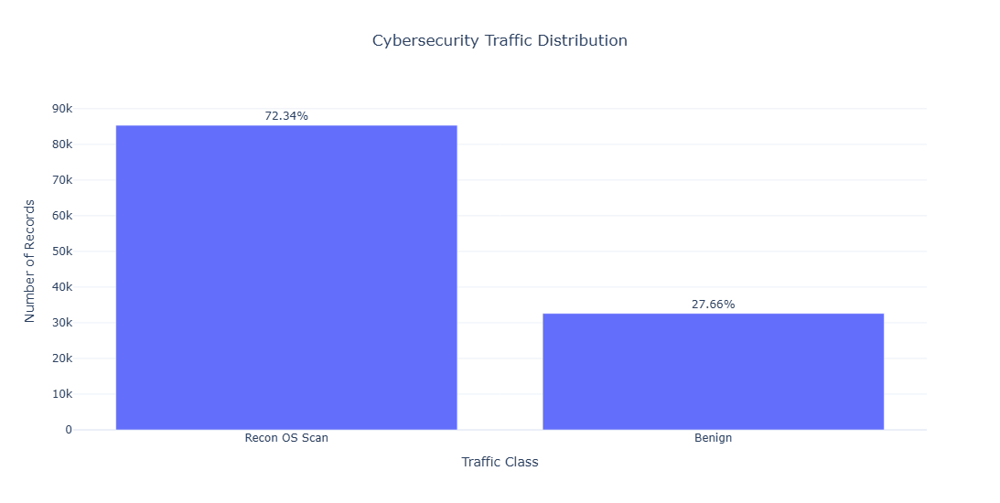

In [21]:
# ============================================
# TASK 3.1 — THREAT LANDSCAPE
# Interactive Label Distribution
# ============================================

import plotly.express as px

# Create a readable label column for visualization
label_counts = (
    combined_df["Label"]
    .map({
        0: "Benign",
        1: "Recon OS Scan"
    })
    .value_counts()
    .rename_axis("Traffic_Class")
    .reset_index(name="Records")
)

# Calculate percentages
total_records = label_counts["Records"].sum()

label_counts["Percentage"] = (
    label_counts["Records"] / total_records * 100
).round(2)

# Interactive bar chart
fig = px.bar(
    label_counts,
    x="Traffic_Class",
    y="Records",
    text="Percentage",
    hover_data={
        "Traffic_Class": True,
        "Records": ":,",
        "Percentage": ":.2f"
    },
    title="Cybersecurity Traffic Distribution",
    labels={
        "Traffic_Class": "Traffic Class",
        "Records": "Number of Records"
    }
)

fig.update_traces(
    texttemplate="%{text}%",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=550,
    title_x=0.5,
    hovermode="x unified"
)

fig.show()

## 3.2 — Destination Port Intelligence

Destination ports provide useful information about network communication
patterns and can help reveal differences between benign traffic and
reconnaissance activity.

This analysis identifies the most frequently observed destination ports
and compares their traffic distribution across the two classes.

In [31]:
# ============================================
# TASK 3 — PROJECT VISUALIZATION THEME
# ============================================

BENIGN_COLOR = "#2E8B57"       # Green
RECON_COLOR = "#D62728"        # Red
NEUTRAL_COLOR = "#1F77B4"      # Blue
WARNING_COLOR = "#FF8C00"      # Orange

TRAFFIC_COLORS = {
    "Benign": BENIGN_COLOR,
    "Recon OS Scan": RECON_COLOR
}

print("Cybersecurity visualization theme ready.")

Cybersecurity visualization theme ready.


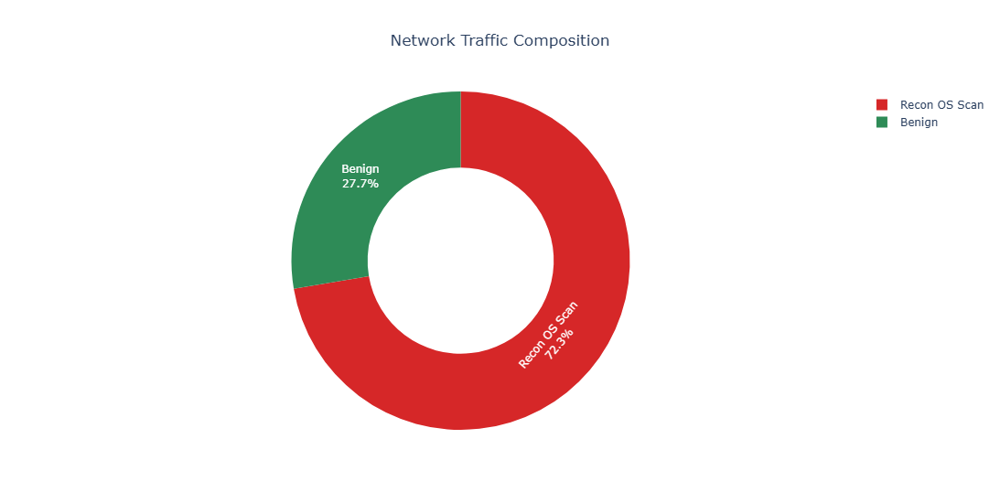

In [32]:
# ============================================
# 3.1 — TRAFFIC COMPOSITION
# ============================================

label_counts = (
    combined_df["Label"]
    .map({
        0: "Benign",
        1: "Recon OS Scan"
    })
    .value_counts()
    .rename_axis("Traffic_Class")
    .reset_index(name="Records")
)

fig = px.pie(
    label_counts,
    names="Traffic_Class",
    values="Records",
    hole=0.55,
    color="Traffic_Class",
    color_discrete_map=TRAFFIC_COLORS,
    title="Network Traffic Composition"
)

fig.update_traces(
    textinfo="percent+label",
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Records: %{value:,}<br>"
        "Share: %{percent}<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=550,
    title_x=0.5
)

fig.show()

In [22]:
# ============================================
# TASK 3.2 — DESTINATION PORT INTELLIGENCE
# ============================================

# Select the most frequently observed destination ports
top_ports = (
    combined_df["Dst Port"]
    .value_counts()
    .head(15)
    .rename_axis("Dst_Port")
    .reset_index(name="Records")
)

# Calculate percentage of total traffic
top_ports["Percentage"] = (
    top_ports["Records"] / len(combined_df) * 100
).round(2)

display(top_ports)

,Dst_Port,Records,Percentage
0,1883,23007,19.51
1,443,2989,2.53
2,8883,1339,1.14
3,59056,1002,0.85
4,64496,1001,0.85
5,63017,1001,0.85
6,58208,1001,0.85
7,52880,1001,0.85
8,43450,1001,0.85
9,49940,1001,0.85


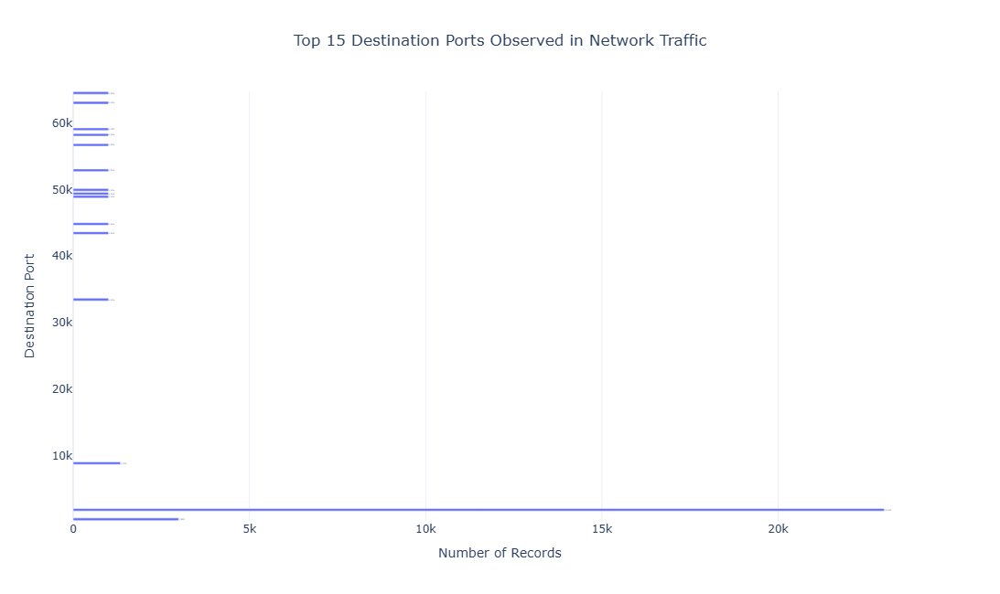

In [23]:
# ============================================
# Interactive Top Destination Ports
# ============================================

fig = px.bar(
    top_ports.sort_values("Records"),
    x="Records",
    y="Dst_Port",
    orientation="h",
    text="Records",
    hover_data={
        "Dst_Port": True,
        "Records": ":,",
        "Percentage": ":.2f"
    },
    title="Top 15 Destination Ports Observed in Network Traffic",
    labels={
        "Dst_Port": "Destination Port",
        "Records": "Number of Records"
    }
)

fig.update_traces(
    texttemplate="%{text:,}",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    title_x=0.5,
    hovermode="y"
)

fig.show()

In [26]:
# ============================================
# TASK 3.2A — CYBERSECURITY PORT CATEGORIES
# ============================================

port_categories = {
    "Web": [80, 443, 8080, 8000, 8008, 8443],
    "Remote Access": [22, 23, 3389],
    "DNS": [53],
    "Email": [25, 110, 143, 465, 587, 993, 995],
    "Database": [1433, 1521, 3306, 5432, 6379, 27017],
    "File Transfer": [20, 21, 69],
    "LDAP": [389, 636],
    "Network Management": [161, 162]
}

def classify_port(port):
    for category, ports in port_categories.items():
        if port in ports:
            return category
    return "Other"

combined_df["Dst_Port_Category"] = (
    combined_df["Dst Port"]
    .apply(classify_port)
)

display(
    combined_df[
        ["Dst Port", "Dst_Port_Category", "Label"]
    ].head(20)
)

,Dst Port,Dst_Port_Category,Label
0,48908,Other,1
1,41953,Other,1
2,53277,Other,1
3,64496,Other,1
4,43631,Other,1
5,1883,Other,0
6,47614,Other,1
7,64486,Other,1
8,41018,Other,1
9,60383,Other,1


In [27]:
# ============================================
# Destination Port Category Distribution
# ============================================

port_category_counts = (
    combined_df
    .groupby(["Dst_Port_Category", "Label"])
    .size()
    .reset_index(name="Records")
)

port_category_counts["Traffic_Class"] = (
    port_category_counts["Label"]
    .map({
        0: "Benign",
        1: "Recon OS Scan"
    })
)

display(
    port_category_counts.sort_values(
        "Records",
        ascending=False
    )
)

,Dst_Port_Category,Label,Records,Traffic_Class
4,Other,1,85133,Recon OS Scan
3,Other,0,29481,Benign
6,Web,0,3139,Benign
7,Web,1,130,Recon OS Scan
5,Remote Access,1,50,Recon OS Scan
1,LDAP,1,2,Recon OS Scan
2,Network Management,1,1,Recon OS Scan
0,Email,1,1,Recon OS Scan


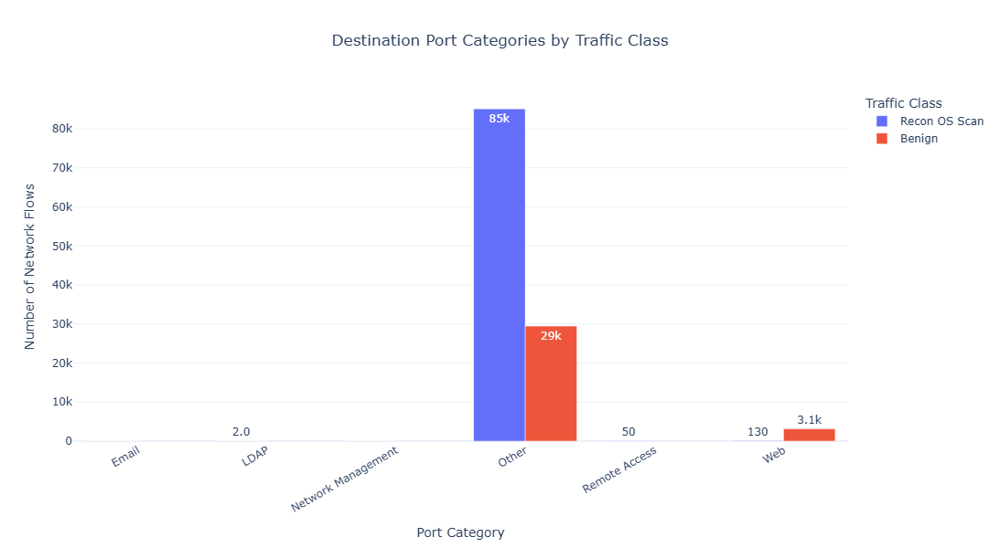

In [28]:
# ============================================
# Interactive Port Category Analysis
# ============================================

fig = px.bar(
    port_category_counts,
    x="Dst_Port_Category",
    y="Records",
    color="Traffic_Class",
    barmode="group",
    text_auto=".2s",
    hover_data={
        "Dst_Port_Category": True,
        "Traffic_Class": True,
        "Records": ":,"
    },
    title="Destination Port Categories by Traffic Class",
    labels={
        "Dst_Port_Category": "Port Category",
        "Records": "Number of Network Flows",
        "Traffic_Class": "Traffic Class"
    }
)

fig.update_layout(
    template="plotly_white",
    height=600,
    title_x=0.5,
    xaxis_tickangle=-30
)

fig.show()

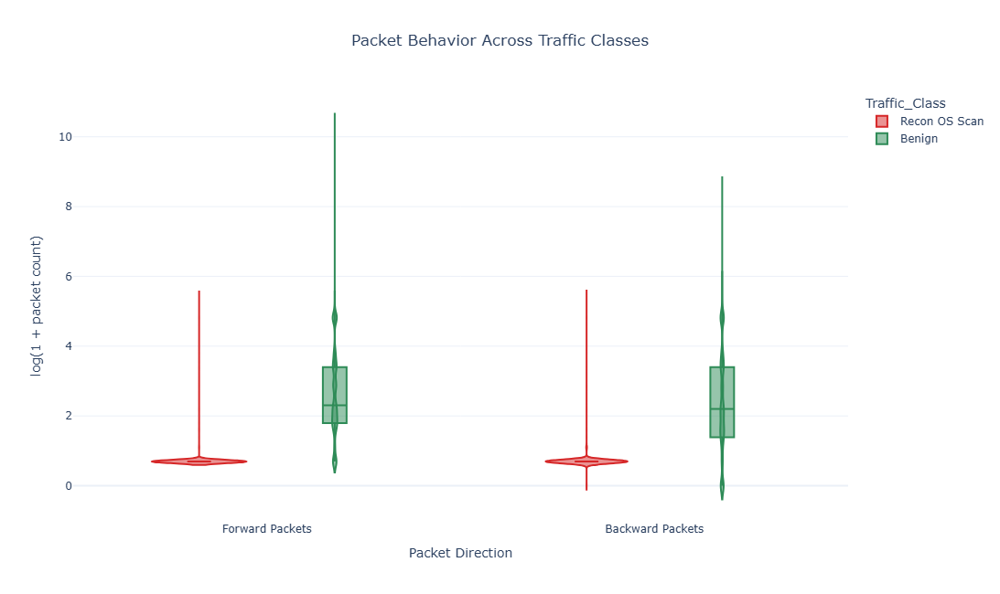

In [34]:
# ============================================
# 3.3 — PACKET BEHAVIOR
# ============================================

packet_data = combined_df[
    [
        "Label",
        "Total Fwd Packet",
        "Total Bwd packets"
    ]
].copy()

packet_data["Traffic_Class"] = packet_data["Label"].map({
    0: "Benign",
    1: "Recon OS Scan"
})

# Log transformation handles the extreme range
packet_data["Log_Fwd_Packets"] = np.log1p(
    packet_data["Total Fwd Packet"]
)

packet_data["Log_Bwd_Packets"] = np.log1p(
    packet_data["Total Bwd packets"]
)

packet_long = packet_data.melt(
    id_vars="Traffic_Class",
    value_vars=[
        "Log_Fwd_Packets",
        "Log_Bwd_Packets"
    ],
    var_name="Packet_Direction",
    value_name="Log_Packet_Count"
)

packet_long["Packet_Direction"] = (
    packet_long["Packet_Direction"]
    .map({
        "Log_Fwd_Packets": "Forward Packets",
        "Log_Bwd_Packets": "Backward Packets"
    })
)

fig = px.violin(
    packet_long,
    x="Packet_Direction",
    y="Log_Packet_Count",
    color="Traffic_Class",
    box=True,
    points=False,
    color_discrete_map=TRAFFIC_COLORS,
    title="Packet Behavior Across Traffic Classes",
    labels={
        "Packet_Direction": "Packet Direction",
        "Log_Packet_Count": "log(1 + packet count)"
    }
)

fig.update_layout(
    template="plotly_white",
    height=650,
    title_x=0.5
)

fig.show()

Label,Dst_Port_Category,0,1,Total,Recon_Share_Percent
0,Email,0,1,1,100.00
1,LDAP,0,2,2,100.00
2,Network Management,0,1,1,100.00
4,Remote Access,0,50,50,100.00
3,Other,29481,85133,114614,74.28
5,Web,3139,130,3269,3.98


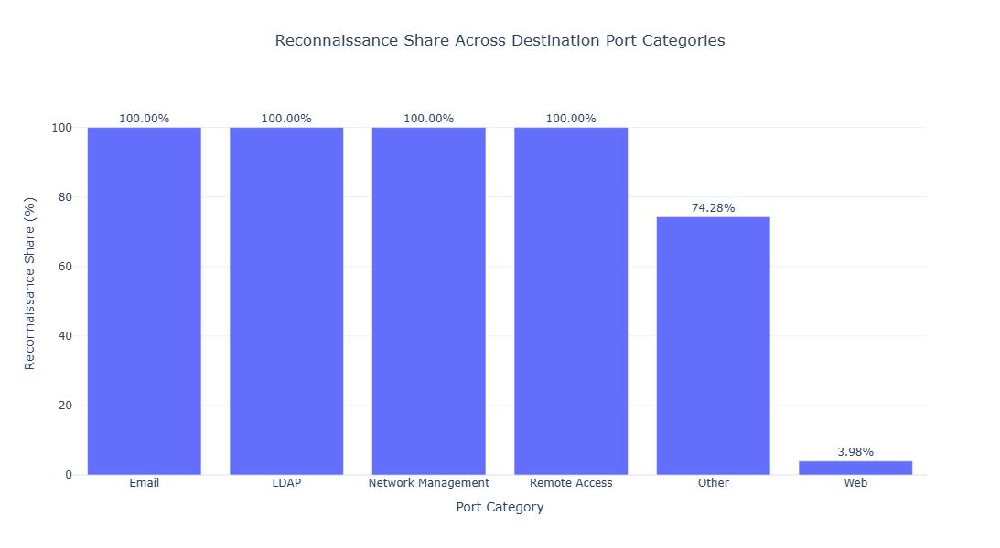

In [30]:
# ============================================
# Reconnaissance Share by Port Category
# ============================================

category_summary = (
    combined_df
    .groupby(["Dst_Port_Category", "Label"])
    .size()
    .unstack(fill_value=0)
)

category_summary["Total"] = (
    category_summary.get(0, 0) +
    category_summary.get(1, 0)
)

category_summary["Recon_Share_Percent"] = (
    category_summary.get(1, 0)
    / category_summary["Total"]
    * 100
).round(2)

category_summary = (
    category_summary
    .reset_index()
    .sort_values(
        "Recon_Share_Percent",
        ascending=False
    )
)

display(category_summary)
# ============================================
# Reconnaissance Share by Port Category
# ============================================

fig = px.bar(
    category_summary,
    x="Dst_Port_Category",
    y="Recon_Share_Percent",
    text="Recon_Share_Percent",
    hover_data={
        "Dst_Port_Category": True,
        "Recon_Share_Percent": ":.2f",
        "Total": ":,"
    },
    title="Reconnaissance Share Across Destination Port Categories",
    labels={
        "Dst_Port_Category": "Port Category",
        "Recon_Share_Percent": "Reconnaissance Share (%)"
    }
)

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    title_x=0.5
)

fig.show()

Decision Tree Performance
----------------------------------------
Accuracy  : 0.9959
Precision : 0.9994
Recall    : 0.9949
F1-score  : 0.9972
Training Time : 1.7253 seconds

Classification Report:

                            precision    recall  f1-score   support

           Benign / Normal       0.99      1.00      0.99      6524
Recon OS Scan / Suspicious       1.00      0.99      1.00     17064

                  accuracy                           1.00     23588
                 macro avg       0.99      1.00      0.99     23588
              weighted avg       1.00      1.00      1.00     23588



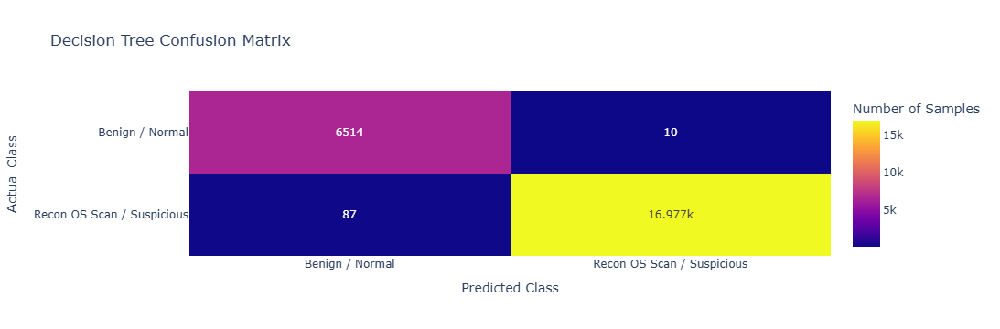

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import time

# -----------------------------
# Train Decision Tree
# -----------------------------

start_time = time.perf_counter()

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(X_train, y_train)

dt_training_time = time.perf_counter() - start_time


# -----------------------------
# Predictions
# -----------------------------

y_pred_dt = dt_model.predict(X_test)


# -----------------------------
# Evaluation Metrics
# -----------------------------

dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, zero_division=0)


print("Decision Tree Performance")
print("-" * 40)

print(f"Accuracy  : {dt_accuracy:.4f}")
print(f"Precision : {dt_precision:.4f}")
print(f"Recall    : {dt_recall:.4f}")
print(f"F1-score  : {dt_f1:.4f}")
print(f"Training Time : {dt_training_time:.4f} seconds")


# -----------------------------
# Classification Report
# -----------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[
            "Benign / Normal",
            "Recon OS Scan / Suspicious"
        ],
        zero_division=0
    )
)


# -----------------------------
# Confusion Matrix
# -----------------------------

cm_dt = confusion_matrix(y_test, y_pred_dt)

fig = px.imshow(
    cm_dt,
    text_auto=True,
    aspect="auto",
    title="Decision Tree Confusion Matrix",
    labels={
        "x": "Predicted Class",
        "y": "Actual Class",
        "color": "Number of Samples"
    },
    x=["Benign / Normal", "Recon OS Scan / Suspicious"],
    y=["Benign / Normal", "Recon OS Scan / Suspicious"]
)

fig.show()

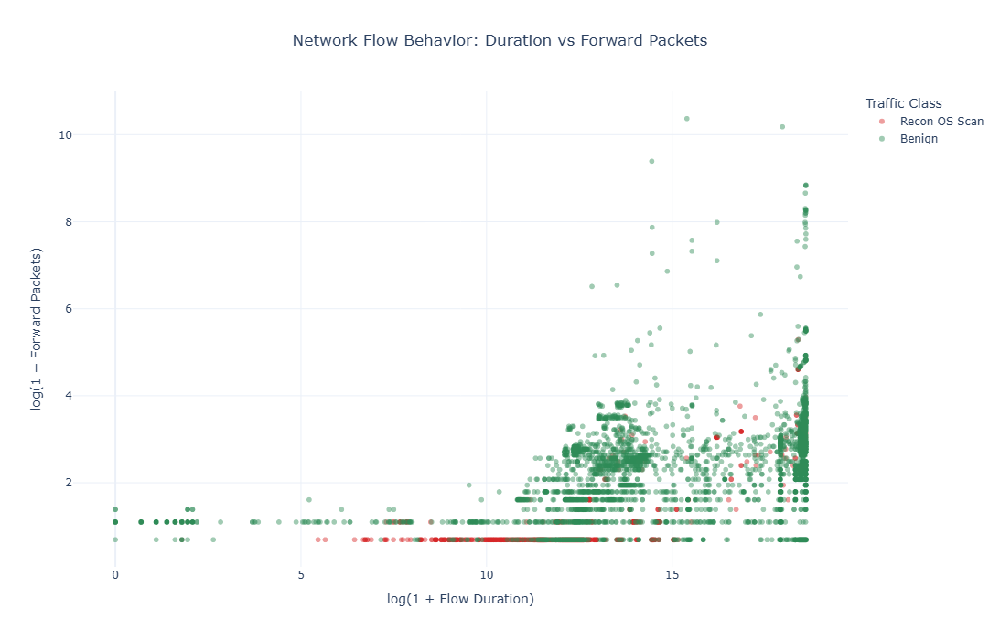

In [35]:
# ============================================
# 3.5 — FLOW BEHAVIOR RELATIONSHIP
# ============================================

scatter_data = combined_df[
    [
        "Flow Duration",
        "Total Fwd Packet",
        "Total Bwd packets",
        "Dst Port",
        "Label"
    ]
].copy()

scatter_data["Traffic_Class"] = scatter_data["Label"].map({
    0: "Benign",
    1: "Recon OS Scan"
})

scatter_data["Log_Flow_Duration"] = np.log1p(
    scatter_data["Flow Duration"]
)

scatter_data["Log_Fwd_Packets"] = np.log1p(
    scatter_data["Total Fwd Packet"]
)

fig = px.scatter(
    scatter_data,
    x="Log_Flow_Duration",
    y="Log_Fwd_Packets",
    color="Traffic_Class",
    color_discrete_map=TRAFFIC_COLORS,
    opacity=0.45,
    hover_data=[
        "Flow Duration",
        "Total Fwd Packet",
        "Total Bwd packets",
        "Dst Port"
    ],
    title="Network Flow Behavior: Duration vs Forward Packets",
    labels={
        "Log_Flow_Duration": "log(1 + Flow Duration)",
        "Log_Fwd_Packets": "log(1 + Forward Packets)",
        "Traffic_Class": "Traffic Class"
    }
)

fig.update_layout(
    template="plotly_white",
    height=700,
    title_x=0.5
)

fig.show()

Top features associated with Label:
['RST Flag Count', 'Flow Duration', 'Fwd Seg Size Min', 'Fwd IAT Total', 'Bwd IAT Total', 'Dst Port', 'Fwd PSH Flags', 'SYN Flag Count', 'Src Port', 'Flow IAT Max', 'Idle Max', 'Idle Mean']


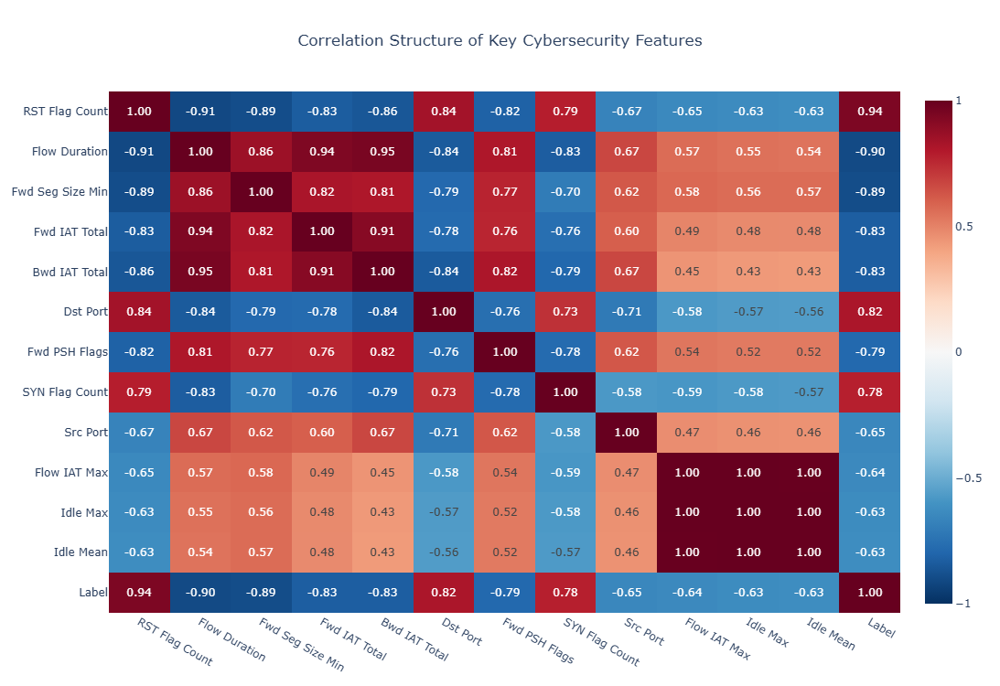

In [37]:
# ============================================
# 3.6 — FEATURE CORRELATION
# ============================================

numeric_df = combined_df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr(numeric_only=True)

# Find strongest correlations with Label
label_correlation = (
    correlation["Label"]
    .drop("Label")
    .abs()
    .sort_values(ascending=False)
)

top_features = label_correlation.head(12).index.tolist()

print("Top features associated with Label:")
print(top_features)
# ============================================
# Correlation Heatmap of Selected Features
# ============================================

selected_features = top_features + ["Label"]

corr_matrix = combined_df[
    selected_features
].corr()

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    zmin=-1,
    zmax=1,
    title="Correlation Structure of Key Cybersecurity Features"
)

fig.update_layout(
    template="plotly_white",
    height=750,
    title_x=0.5
)

fig.show()

In [41]:
# ============================================================
# TASK 5 — MACHINE LEARNING CLASSIFICATION
# AI-Driven Cyber Threat Awareness and Detection Prototype
# ============================================================

# ------------------------------------------------------------
# 5.1 IMPORT REQUIRED LIBRARIES
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")


# ------------------------------------------------------------
# 5.2 PREPARE DATA
# ------------------------------------------------------------

# Work on a copy so the original combined_df remains unchanged
ml_df = combined_df.copy()

# Target variable
# 0 = Benign / Normal
# 1 = Recon OS Scan / Suspicious
y = ml_df["Label"]

# Columns that must NOT be used as ML features
# Label = target
# Traffic_Type = directly reveals source/class
# Dst_Port_Category = EDA-derived categorical information
columns_to_drop = [
    "Label",
    "Traffic_Type",
    "Dst_Port_Category"
]

# Drop only columns that exist
columns_to_drop = [
    column for column in columns_to_drop
    if column in ml_df.columns
]

X = ml_df.drop(columns=columns_to_drop)

# Keep numerical features only
X = X.select_dtypes(include=np.number)

print("\nOriginal dataset shape:", combined_df.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


# ------------------------------------------------------------
# 5.3 REMOVE CONSTANT FEATURES
# ------------------------------------------------------------

constant_features = [
    column
    for column in X.columns
    if X[column].nunique() <= 1
]

if constant_features:
    X = X.drop(columns=constant_features)

print("\nConstant features removed:")
print(constant_features)

print("\nFeatures remaining:", X.shape[1])


# ------------------------------------------------------------
# 5.4 HANDLE INVALID VALUES
# ------------------------------------------------------------

# Replace infinite values with NaN
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values using the median of each feature
X = X.fillna(X.median())

print("\nMissing values remaining:", X.isna().sum().sum())
print("Infinite values remaining:", np.isinf(X).sum().sum())


# ------------------------------------------------------------
# 5.5 TRAIN-TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())


# ------------------------------------------------------------
# 5.6 FEATURE SCALING
# ------------------------------------------------------------

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ------------------------------------------------------------
# 5.7 TRAIN LOGISTIC REGRESSION MODEL
# ------------------------------------------------------------

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


# ------------------------------------------------------------
# 5.8 MAKE PREDICTIONS
# ------------------------------------------------------------

y_pred = model.predict(X_test_scaled)

print("\nPredictions generated successfully.")
print("Number of predictions:", len(y_pred))


# ------------------------------------------------------------
# 5.9 CALCULATE PERFORMANCE METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)


# ------------------------------------------------------------
# 5.10 DISPLAY PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"Accuracy :  {accuracy:.4f}  ({accuracy * 100:.2f}%)")
print(f"Precision:  {precision:.4f}")
print(f"Recall   :  {recall:.4f}")
print(f"F1-score :  {f1:.4f}")


# ------------------------------------------------------------
# 5.11 CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Benign / Normal",
            "Recon OS Scan / Suspicious"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 5.12 CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

print(cm)



# ------------------------------------------------------------
# 5.13 PERFORMANCE SUMMARY TABLE
# ------------------------------------------------------------

evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

evaluation_results["Score"] = evaluation_results["Score"].round(4)

print("\n" + "=" * 60)
print("PERFORMANCE SUMMARY")
print("=" * 60)

display(evaluation_results)

Libraries imported successfully.

Original dataset shape: (117937, 87)
Feature matrix shape: (117937, 79)
Target shape: (117937,)

Constant features removed:
['Protocol', 'Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Bytes/Bulk Avg', 'Fwd Packet/Bulk Avg', 'Fwd Bulk Rate Avg']

Features remaining: 73

Missing values remaining: 0
Infinite values remaining: 0

Training samples: 94349
Testing samples: 23588

Training class distribution:
Label
1    68253
0    26096
Name: count, dtype: int64

Testing class distribution:
Label
1    17064
0     6524
Name: count, dtype: int64

Feature scaling completed.
Logistic Regression model trained successfully.

Predictions generated successfully.
Number of predictions: 23588

MODEL PERFORMANCE
Accuracy :  0.9928  (99.28%)
Precision:  0.9956
Recall   :  0.9945
F1-score :  0.9950

CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Benign / Normal       0.99      0.99      0.99      6524
Recon OS Scan / Suspiciou

,Metric,Score
0,Accuracy,0.9928
1,Precision,0.9956
2,Recall,0.9945
3,F1-score,0.9950


DECISION TREE CLASSIFIER

Training Decision Tree...

Decision Tree training completed.
Training time: 1.3554 seconds
Prediction time: 0.0147 seconds

DECISION TREE PERFORMANCE
Accuracy :  0.9959 (99.59%)
Precision:  0.9994
Recall   :  0.9949
F1-score :  0.9972

DECISION TREE CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Benign / Normal       0.99      1.00      0.99      6524
Recon OS Scan / Suspicious       1.00      0.99      1.00     17064

                  accuracy                           1.00     23588
                 macro avg       0.99      1.00      0.99     23588
              weighted avg       1.00      1.00      1.00     23588


DECISION TREE CONFUSION MATRIX
[[ 6514    10]
 [   87 16977]]


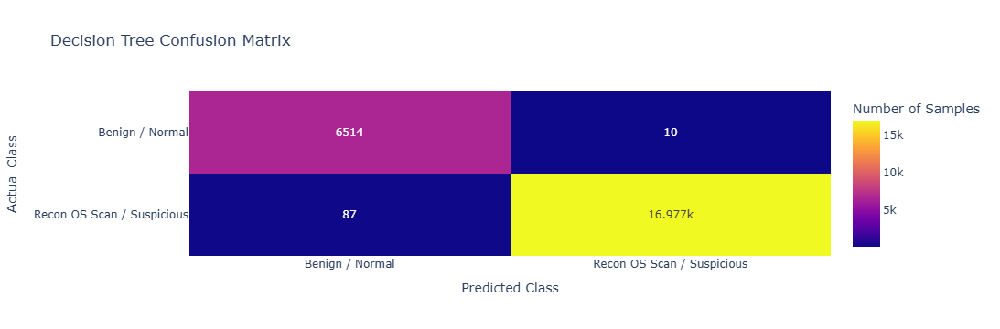


TOP 15 IMPORTANT FEATURES


,Feature,Importance
46,ACK Flag Count,0.9802
36,Bwd Packets/s,0.0132
44,RST Flag Count,0.0019
0,Src Port,0.0016
20,Flow IAT Min,0.0009
1,Dst Port,0.0003
62,Bwd Init Win Bytes,0.0003
64,Fwd Seg Size Min,0.0003
35,Fwd Packets/s,0.0003
43,SYN Flag Count,0.0002


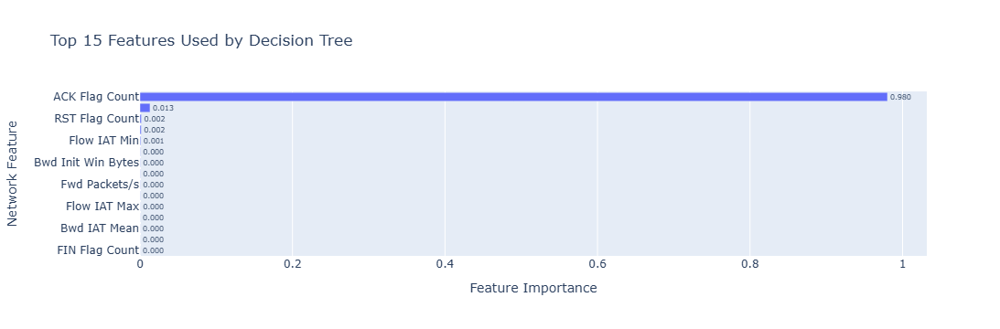

In [47]:
# ============================================================
# TASK 5.5 — DECISION TREE CLASSIFIER
# AI-Driven Cyber Threat Awareness and Detection Prototype
# ============================================================

import time
import pandas as pd
import plotly.express as px

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 5.5.1 TRAIN THE DECISION TREE
# ------------------------------------------------------------

print("=" * 60)
print("DECISION TREE CLASSIFIER")
print("=" * 60)

print("\nTraining Decision Tree...")

start_time = time.perf_counter()

dt_model = DecisionTreeClassifier(
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)

dt_model.fit(
    X_train,
    y_train
)

end_time = time.perf_counter()

dt_training_time = end_time - start_time

print("\nDecision Tree training completed.")
print(f"Training time: {dt_training_time:.4f} seconds")


# ------------------------------------------------------------
# 5.5.2 MAKE PREDICTIONS
# ------------------------------------------------------------

start_prediction_time = time.perf_counter()

y_pred_dt = dt_model.predict(X_test)

end_prediction_time = time.perf_counter()

dt_prediction_time = end_prediction_time - start_prediction_time

print(f"Prediction time: {dt_prediction_time:.4f} seconds")


# ------------------------------------------------------------
# 5.5.3 CALCULATE PERFORMANCE METRICS
# ------------------------------------------------------------

dt_accuracy = accuracy_score(
    y_test,
    y_pred_dt
)

dt_precision = precision_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

dt_recall = recall_score(
    y_test,
    y_pred_dt,
    zero_division=0
)

dt_f1 = f1_score(
    y_test,
    y_pred_dt,
    zero_division=0
)


# ------------------------------------------------------------
# 5.5.4 DISPLAY PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DECISION TREE PERFORMANCE")
print("=" * 60)

print(f"Accuracy :  {dt_accuracy:.4f} ({dt_accuracy * 100:.2f}%)")
print(f"Precision:  {dt_precision:.4f}")
print(f"Recall   :  {dt_recall:.4f}")
print(f"F1-score :  {dt_f1:.4f}")


# ------------------------------------------------------------
# 5.5.5 CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DECISION TREE CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_dt,
        target_names=[
            "Benign / Normal",
            "Recon OS Scan / Suspicious"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 5.5.6 CONFUSION MATRIX
# ------------------------------------------------------------

dt_cm = confusion_matrix(
    y_test,
    y_pred_dt
)

print("\n" + "=" * 60)
print("DECISION TREE CONFUSION MATRIX")
print("=" * 60)

print(dt_cm)

fig = px.imshow(
    dt_cm,
    text_auto=True,
    aspect="auto",
    title="Decision Tree Confusion Matrix",
    labels={
        "x": "Predicted Class",
        "y": "Actual Class",
        "color": "Number of Samples"
    },
    x=[
        "Benign / Normal",
        "Recon OS Scan / Suspicious"
    ],
    y=[
        "Benign / Normal",
        "Recon OS Scan / Suspicious"
    ]
)

fig.show()


# ------------------------------------------------------------
# 5.5.7 FEATURE IMPORTANCE
# ------------------------------------------------------------

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": dt_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .head(15)
)

print("\n" + "=" * 60)
print("TOP 15 IMPORTANT FEATURES")
print("=" * 60)

display(
    feature_importance.round(4)
)


# ------------------------------------------------------------
# 5.5.8 FEATURE IMPORTANCE VISUALIZATION
# ------------------------------------------------------------

fig = px.bar(
    feature_importance.sort_values("Importance"),
    x="Importance",
    y="Feature",
    orientation="h",
    title="Top 15 Features Used by Decision Tree",
    labels={
        "Importance": "Feature Importance",
        "Feature": "Network Feature"
    },
    text="Importance"
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.show()

# Task 6 — Deep Learning Prototype Implementation

Deep Learning is a branch of machine learning that uses artificial
neural networks containing multiple interconnected layers to learn
patterns from data.

In this task, a simple Multi-Layer Perceptron (MLP) neural network
is implemented using scikit-learn's MLPClassifier.

The same training and testing dataset used for the Logistic Regression
model is used so that the machine learning and deep learning approaches
can be compared fairly.

The comparison focuses on:

- Training time
- Detection accuracy
- Precision
- Recall
- F1-score
- Practical feasibility

DEEP LEARNING — MLP CLASSIFIER

Training neural network...

Neural network training completed.
Training time: 9.56 seconds
Training iterations: 16
Prediction time: 0.0235 seconds

NEURAL NETWORK PERFORMANCE
Accuracy :  0.9956 (99.56%)
Precision:  0.9992
Recall   :  0.9947
F1-score :  0.9969

NEURAL NETWORK CLASSIFICATION REPORT
                            precision    recall  f1-score   support

           Benign / Normal       0.99      1.00      0.99      6524
Recon OS Scan / Suspicious       1.00      0.99      1.00     17064

                  accuracy                           1.00     23588
                 macro avg       0.99      1.00      0.99     23588
              weighted avg       1.00      1.00      1.00     23588


NEURAL NETWORK CONFUSION MATRIX
[[ 6510    14]
 [   90 16974]]

MACHINE LEARNING VS DEEP LEARNING


,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds)
0,Logistic Regression,0.9928,0.9956,0.9945,0.9950,NaN
1,MLP Neural Network,0.9956,0.9992,0.9947,0.9969,9.5598


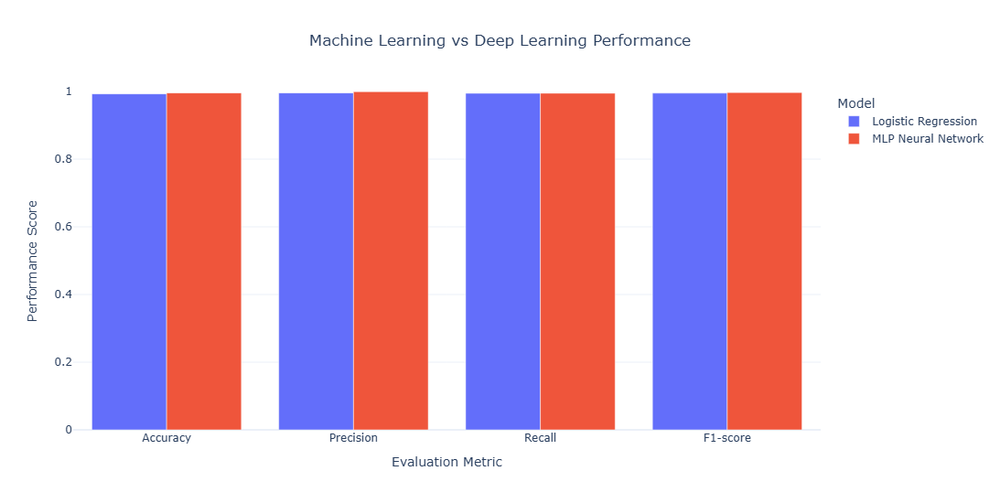


MLP training time:
9.56 seconds

PRACTICAL FEASIBILITY

Accuracy comparison:
MLP achieved higher accuracy than Logistic Regression.
Accuracy difference: 0.28 percentage points

Training time:
MLP Neural Network: 9.56 seconds

Practical considerations:

• Logistic Regression is simpler and generally easier to interpret.
• The MLP can learn non-linear relationships between network features.
• The neural network requires more computational resources than the
  simple baseline model.
• The final choice should depend on detection performance, training
  cost, interpretability, and deployment requirements.


TASK 6 COMPLETED

A Multi-Layer Perceptron neural network was successfully implemented
using scikit-learn's MLPClassifier.

The neural network was trained on the same dataset and scaled features
used by the Logistic Regression baseline.

Both approaches were evaluated using accuracy, precision, recall,
and F1-score. Training time was also recorded to assess practical
feasibility.

The r

In [42]:
# ============================================================
# TASK 6 — DEEP LEARNING PROTOTYPE
# AI-Driven Cyber Threat Awareness and Detection Prototype
# ============================================================

import time
import numpy as np
import pandas as pd
import plotly.express as px

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ------------------------------------------------------------
# 6.1 TRAIN THE NEURAL NETWORK
# ------------------------------------------------------------

print("=" * 60)
print("DEEP LEARNING — MLP CLASSIFIER")
print("=" * 60)

print("\nTraining neural network...")

start_time = time.perf_counter()

mlp_model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.10,
    n_iter_no_change=10
)

mlp_model.fit(
    X_train_scaled,
    y_train
)

end_time = time.perf_counter()

training_time = end_time - start_time

print("\nNeural network training completed.")
print(f"Training time: {training_time:.2f} seconds")
print(f"Training iterations: {mlp_model.n_iter_}")


# ------------------------------------------------------------
# 6.2 MAKE PREDICTIONS
# ------------------------------------------------------------

start_prediction_time = time.perf_counter()

y_pred_mlp = mlp_model.predict(X_test_scaled)

end_prediction_time = time.perf_counter()

prediction_time = end_prediction_time - start_prediction_time

print(f"Prediction time: {prediction_time:.4f} seconds")


# ------------------------------------------------------------
# 6.3 CALCULATE PERFORMANCE METRICS
# ------------------------------------------------------------

mlp_accuracy = accuracy_score(
    y_test,
    y_pred_mlp
)

mlp_precision = precision_score(
    y_test,
    y_pred_mlp,
    zero_division=0
)

mlp_recall = recall_score(
    y_test,
    y_pred_mlp,
    zero_division=0
)

mlp_f1 = f1_score(
    y_test,
    y_pred_mlp,
    zero_division=0
)


# ------------------------------------------------------------
# 6.4 DISPLAY PERFORMANCE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NEURAL NETWORK PERFORMANCE")
print("=" * 60)

print(f"Accuracy :  {mlp_accuracy:.4f} ({mlp_accuracy * 100:.2f}%)")
print(f"Precision:  {mlp_precision:.4f}")
print(f"Recall   :  {mlp_recall:.4f}")
print(f"F1-score :  {mlp_f1:.4f}")


# ------------------------------------------------------------
# 6.5 CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("NEURAL NETWORK CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_mlp,
        target_names=[
            "Benign / Normal",
            "Recon OS Scan / Suspicious"
        ],
        zero_division=0
    )
)


# ------------------------------------------------------------
# 6.6 CONFUSION MATRIX
# ------------------------------------------------------------

mlp_cm = confusion_matrix(
    y_test,
    y_pred_mlp
)

print("\n" + "=" * 60)
print("NEURAL NETWORK CONFUSION MATRIX")
print("=" * 60)

print(mlp_cm)


# ------------------------------------------------------------
# 6.7 COMPARE ML VS DL
# ------------------------------------------------------------

# Logistic Regression results from Task 5
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "MLP Neural Network"
    ],
    "Accuracy": [
        accuracy,
        mlp_accuracy
    ],
    "Precision": [
        precision,
        mlp_precision
    ],
    "Recall": [
        recall,
        mlp_recall
    ],
    "F1-score": [
        f1,
        mlp_f1
    ],
    "Training Time (seconds)": [
        np.nan,
        training_time
    ]
})

print("\n" + "=" * 60)
print("MACHINE LEARNING VS DEEP LEARNING")
print("=" * 60)

display(
    comparison.round(4)
)

# ------------------------------------------------------------
# 6.9 TRAINING TIME COMPARISON
# ------------------------------------------------------------

training_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "MLP Neural Network"
    ],
    "Training Time (seconds)": [
        np.nan,
        training_time
    ]
})

print("\nMLP training time:")
print(f"{training_time:.2f} seconds")


# ------------------------------------------------------------
# 6.10 PRACTICAL FEASIBILITY ANALYSIS
# ------------------------------------------------------------

performance_difference = mlp_accuracy - accuracy

if performance_difference > 0:
    accuracy_result = "MLP achieved higher accuracy than Logistic Regression."
elif performance_difference < 0:
    accuracy_result = "Logistic Regression achieved higher accuracy than MLP."
else:
    accuracy_result = "Both models achieved the same accuracy."


print("\n" + "=" * 60)
print("PRACTICAL FEASIBILITY")
print("=" * 60)

print("\nAccuracy comparison:")
print(accuracy_result)

print(
    f"Accuracy difference: "
    f"{abs(performance_difference) * 100:.2f} percentage points"
)

print("\nTraining time:")
print(f"MLP Neural Network: {training_time:.2f} seconds")


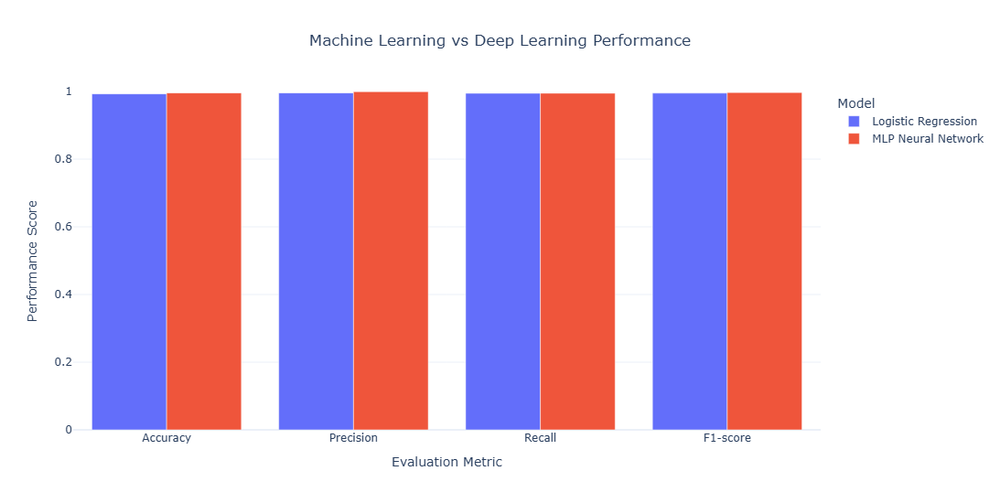

In [43]:
# ------------------------------------------------------------
# 6.8 PERFORMANCE COMPARISON CHART
# ------------------------------------------------------------

performance_long = comparison.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],
    var_name="Metric",
    value_name="Score"
)

fig = px.bar(
    performance_long,
    x="Metric",
    y="Score",
    color="Model",
    barmode="group",
    text="Score",
    title="Machine Learning vs Deep Learning Performance",
    labels={
        "Score": "Performance Score",
        "Metric": "Evaluation Metric",
        "Model": "Model"
    }
)

fig.update_traces(
    texttemplate="%{text:.3f}",
    textposition="outside"
)

fig.update_yaxes(
    range=[0, 1]
)

fig.update_layout(
    template="plotly_white",
    height=550,
    title_x=0.5
)

fig.show()

